# Day 35 (2/3) — Ridge: 4 Key Understandings in Pictures

This notebook is mostly **pictures**. Each one answers one question about Ridge:

| # | Question |
|---|---|
| 1 | What happens to the coefficients as α grows? |
| 2 | Which coefficients shrink the most? |
| 3 | How does α trade **bias** against **variance**? |
| 4 | Why does the penalty pull weights toward 0? (loss curve + geometry) |

> 🎨 Most code here is *visualization only*: run it and focus on the plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
features = X.columns
print(X.shape)
X.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


---
## 1. Coefficients shrink as α grows

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

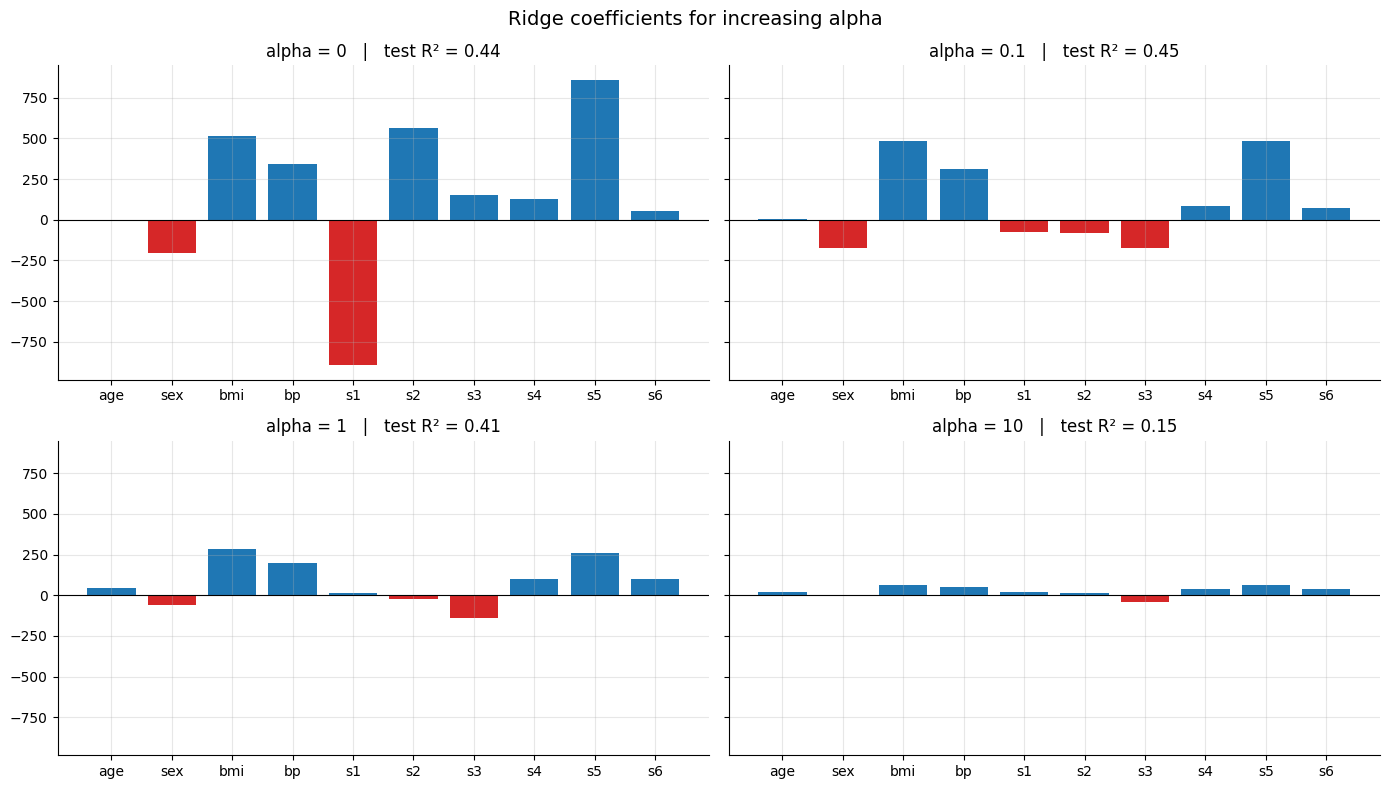

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
for ax, alpha in zip(axes.ravel(), [0, 0.1, 1, 10]):
    model = Ridge(alpha=alpha).fit(X_train, y_train)
    r2 = r2_score(y_test, model.predict(X_test))
    ax.bar(features, model.coef_, color=np.where(model.coef_ >= 0, 'tab:blue', 'tab:red'))
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'alpha = {alpha}   |   test R² = {r2:.2f}')
plt.suptitle('Ridge coefficients for increasing alpha', fontsize=14)
plt.tight_layout()
plt.show()

Every bar gets shorter as α increases, but **none disappears**. Ridge never sets a coefficient to exactly 0.

---
## 2. Bigger coefficients shrink the most

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

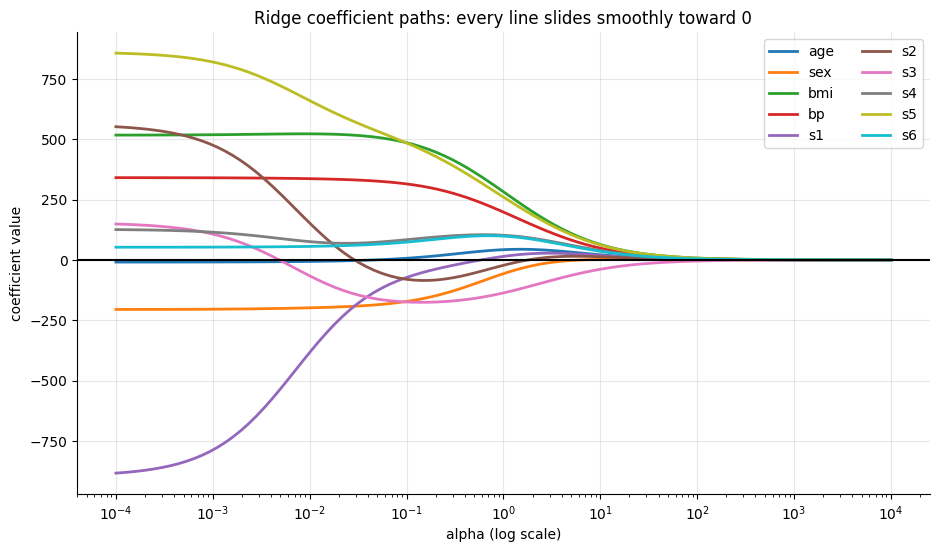

In [4]:
alphas = np.logspace(-4, 4, 100)
paths = np.array([Ridge(alpha=a).fit(X_train, y_train).coef_ for a in alphas])

plt.figure(figsize=(11, 6))
for j, name in enumerate(features):
    plt.plot(alphas, paths[:, j], linewidth=2, label=name)
plt.axhline(0, color='black', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('coefficient value')
plt.title('Ridge coefficient paths: every line slides smoothly toward 0')
plt.legend(ncol=2)
plt.show()

> ✍️ **Core code: learn this.** Reading the same information as a table.

In [5]:
table = pd.DataFrame([Ridge(alpha=a).fit(X_train, y_train).coef_ for a in [0, 0.1, 1, 10, 100]],
                     columns=features, index=pd.Index([0, 0.1, 1, 10, 100], name='alpha')).round(1)
table

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0,-9.2,-205.5,516.7,340.6,-895.6,561.2,153.9,126.7,861.1,52.4
0.1,6.6,-172.2,485.5,314.7,-72.9,-80.6,-174.5,83.6,484.4,73.6
1.0,42.2,-57.3,282.2,198.1,14.4,-22.6,-136.9,102.0,260.1,98.6
10.0,21.2,1.7,63.7,48.5,18.4,12.9,-38.9,38.8,61.6,35.5
100.0,2.9,0.6,7.5,5.8,2.7,2.1,-4.8,5.1,7.4,4.6


Look at **`s1`**: it starts as the largest weight (≈ −900) and collapses to ≈ −70 already at α = 0.1.
`s2` and `s5` (also huge at α = 0) shrink fast too. Meanwhile a small weight like `age` can even *grow* for a while:
when the oversized, correlated weights are tamed, the model redistributes their job among the other features.
At large α, every weight heads to 0 together.

Why are the big ones hit first? The penalty is $w^2$, and its push on a weight is $2\alpha w$, **proportional to the weight itself**.
A big weight feels a big push. This is why Ridge tames the wild, oversized coefficients of an overfit model first.

---
## 3. The bias–variance trade-off

We generate **200 different training sets** from the same true curve, fit a degree-12 polynomial with Ridge on each,
and measure:
- **Bias²**: how far the *average* prediction is from the truth (model too simple → high bias)
- **Variance**: how much predictions *jump around* between training sets (model too flexible → high variance)

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

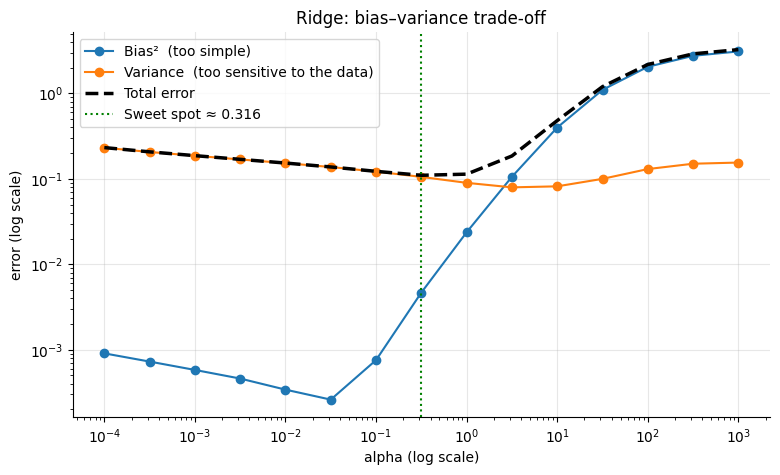

In [6]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)   # some tiny-alpha fits stop early; harmless here
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

def true_f(x):
    return 0.7 * x**2 - 2 * x + 3

x_grid = np.linspace(-1.5, 2.5, 50)
alphas_bv = np.logspace(-4, 3, 15)
bias2, variance = [], []

for a in alphas_bv:
    rng = np.random.default_rng(0)
    preds = []
    for _ in range(200):                                  # 200 different training sets
        x = rng.uniform(-2, 3, 40)
        y_noisy = true_f(x) + rng.normal(0, 1, 40)
        model = make_pipeline(PolynomialFeatures(12, include_bias=False), StandardScaler(),
                              Ridge(alpha=a, max_iter=20000))
        model.fit(x.reshape(-1, 1), y_noisy)
        preds.append(model.predict(x_grid.reshape(-1, 1)))
    preds = np.array(preds)
    bias2.append(((preds.mean(axis=0) - true_f(x_grid)) ** 2).mean())
    variance.append(preds.var(axis=0).mean())

bias2, variance = np.array(bias2), np.array(variance)
total = bias2 + variance
best = alphas_bv[total.argmin()]

plt.figure(figsize=(9, 5))
plt.plot(alphas_bv, bias2, 'o-', label='Bias²  (too simple)')
plt.plot(alphas_bv, variance, 'o-', label='Variance  (too sensitive to the data)')
plt.plot(alphas_bv, total, 'k--', linewidth=2.5, label='Total error')
plt.axvline(best, color='green', linestyle=':', label=f'Sweet spot ≈ {best:.3g}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('error (log scale)')
plt.title('Ridge: bias–variance trade-off')
plt.legend()
plt.show()

- **Small α**: low bias, higher variance (the model chases noise).
- **Large α**: variance drops but bias explodes (the model becomes too stiff).
- The **sweet spot** in between gives the lowest total error. That is the α cross-validation looks for.

---
## 4. Why the penalty pulls weights toward 0

### 4a. The loss curve
Back to the one-feature line $\hat y = m x + b$. We plot the Ridge loss for every possible slope $m$
(intercept fixed at its fitted value) and mark the minimum.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

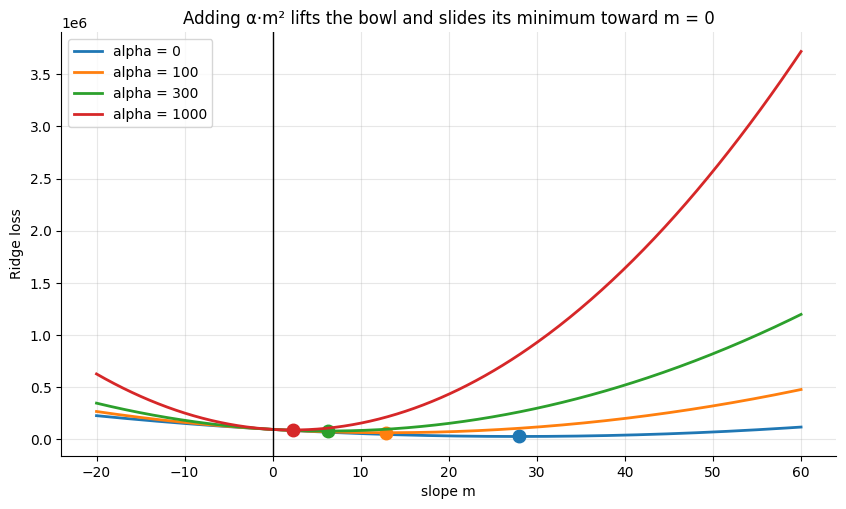

In [7]:
from sklearn.datasets import make_regression

X1, y1 = make_regression(n_samples=100, n_features=1, noise=20, random_state=13)
b = LinearRegression().fit(X1, y1).intercept_
m_values = np.linspace(-20, 60, 400)

plt.figure(figsize=(10, 5.5))
for alpha in [0, 100, 300, 1000]:
    loss = np.array([np.sum((y1 - (m * X1.ravel() + b))**2) + alpha * m**2 for m in m_values])
    line, = plt.plot(m_values, loss, linewidth=2, label=f'alpha = {alpha}')
    plt.plot(m_values[loss.argmin()], loss.min(), 'o', color=line.get_color(), markersize=9)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('slope m')
plt.ylabel('Ridge loss')
plt.title('Adding α·m² lifts the bowl and slides its minimum toward m = 0')
plt.legend()
plt.show()

Each curve is a smooth bowl. Adding $\alpha m^2$ makes the bowl steeper and moves its lowest point **toward 0**,
but a smooth bowl's minimum never lands *exactly* on 0. Compare this with Lasso tomorrow.

### 4b. The geometry (two weights)
Ridge is equivalent to: *minimise the error, but keep $w_1^2 + w_2^2 \le t$*, i.e. the weights must stay inside a **circle**.
The grey ellipses are contours of equal error; the solution is where the smallest ellipse touches the circle.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

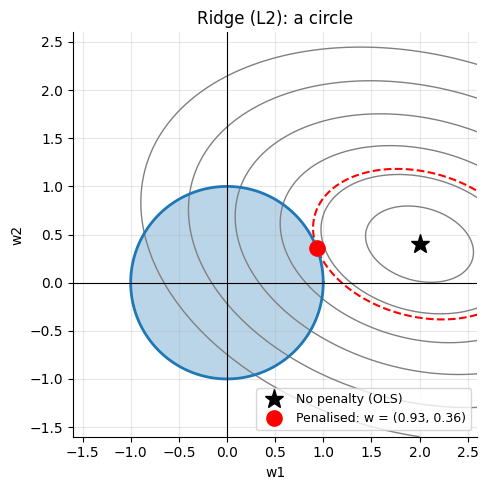

In [8]:
# A 2-feature problem: the error (RSS) surface is a bowl whose lowest point is the OLS solution
A = np.array([[1.0, 0.3], [0.3, 2.0]])
w_ols = np.array([2.0, 0.4])
rss = lambda w1, w2: (A[0, 0] * (w1 - w_ols[0])**2 + 2 * A[0, 1] * (w1 - w_ols[0]) * (w2 - w_ols[1])
                      + A[1, 1] * (w2 - w_ols[1])**2)

def boundary(radius_fn, n=4000):
    th = np.linspace(0, 2 * np.pi, n)
    d = np.c_[np.cos(th), np.sin(th)]
    r = np.array([radius_fn(v) for v in d])
    return d * r[:, None]

def best_on(points):
    return points[np.argmin(rss(points[:, 0], points[:, 1]))]

shapes = [('Ridge (L2): a circle', lambda d: 1.0, 'tab:blue')]

g = np.linspace(-1.6, 2.6, 300)
G1, G2 = np.meshgrid(g, g)
fig, axes = plt.subplots(1, len(shapes), figsize=(5.2 * len(shapes), 5))
axes = np.atleast_1d(axes)
for ax, (name, fn, color) in zip(axes, shapes):
    pts = boundary(fn)
    w = best_on(pts)
    ax.contour(G1, G2, rss(G1, G2), levels=[0.3, 1, 2, 3.5, 5.5, 8], colors='gray', linewidths=1)
    ax.contour(G1, G2, rss(G1, G2), levels=[rss(*w)], colors='red', linestyles='--', linewidths=1.5)
    ax.fill(pts[:, 0], pts[:, 1], color=color, alpha=0.3)
    ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=2)
    ax.plot(*w_ols, 'k*', markersize=14, label='No penalty (OLS)')
    ax.plot(*w, 'o', color='red', markersize=11, label=f'Penalised: w = ({w[0]:.2f}, {w[1]:.2f})')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_aspect('equal')
    ax.set_xlim(-1.6, 2.6)
    ax.set_ylim(-1.6, 2.6)
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title(name)
    ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

The penalised solution (red) is pulled from the OLS point (★) to the circle's edge. Both weights get smaller,
but neither becomes 0: a circle has no corners, so the touching point is almost never on an axis.

---
## 🧠 Quick check

<details><summary>1. In picture 2, why did `s1` change the most?</summary>

The penalty's push is proportional to the weight ($2\alpha w$), so the biggest weight is pushed hardest.
</details>

<details><summary>2. α is too large. Is the model suffering from bias or variance?</summary>

Bias (underfitting): weights are crushed and the model is too simple.
</details>

<details><summary>3. Using the circle picture, why doesn't Ridge produce zeros?</summary>

The circle is smooth with no corners, so the error ellipse touches it at a point where both weights are usually non-zero.
</details>

➡️ **Next:** `03-EXTRA-ridge-from-scratch.ipynb`: write Ridge yourself in three ways.